# Analisis Kompleksitas Algoritma - Kelompok 2

**Algoritma yang Dianalisis:**
1. Linear Search - O(n)
2. Binary Search - O(log n)
3. Bubble Sort - O(n²)
4. Insertion Sort - O(n²)
5. Merge Sort - O(n log n)

Notebook ini menyajikan hasil analisis komprehensif dari 4 CSV file:
- `comparison_all_algorithms.csv`
- `comparison_summary.csv`
- `comparison_speedup.csv`
- `comparison_growth_rate.csv`

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
cwd = Path.cwd()
# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.6f}'.format)

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


---
## 1️⃣ Data Lengkap Semua Algoritma

Tabel ini menampilkan **semua hasil testing** untuk 5 algoritma dengan berbagai ukuran input dan tipe data.

In [2]:
# Load data lengkap
df_all = pd.read_csv(cwd.parent / 'results' / 'comparison_all_algorithms.csv')

print(f"Total Records: {len(df_all)}")
print(f"\nAlgoritma yang ditest: {df_all['Algorithm'].unique()}")
print(f"Tipe data: {df_all['Data Type'].unique()}")
print(f"\nPreview data:")
df_all.head(20)

Total Records: 121

Algoritma yang ditest: ['Linear Search' 'Binary Search' 'Bubble Sort' 'Selection Sort'
 'Insertion Sort' 'Merge Sort' 'Quick Sort']
Tipe data: ['Sorted' 'Random' 'Reverse']

Preview data:


,Algorithm,Data Type,Input Size (n),Comparisons,Time (seconds),Complexity Class,Notes
0,Linear Search,Sorted,1000,901,0.000147,O(n),Target at 90%
1,Binary Search,Sorted,1000,10,0.000010,O(log n),Target at 90%
2,Linear Search,Sorted,5000,4501,0.000735,O(n),Target at 90%
3,Binary Search,Sorted,5000,9,0.000009,O(log n),Target at 90%
4,Linear Search,Sorted,10000,9000,0.001062,O(n),Target at 90%
5,Binary Search,Sorted,10000,12,0.000004,O(log n),Target at 90%
6,Linear Search,Sorted,50000,45001,0.007934,O(n),Target at 90%
7,Binary Search,Sorted,50000,16,0.000009,O(log n),Target at 90%
8,Linear Search,Sorted,100000,90000,0.016170,O(n),Target at 90%
9,Binary Search,Sorted,100000,13,0.000009,O(log n),Target at 90%


In [3]:
df_search1 = df_all[df_all['Algorithm'].isin(['Linear Search', 'Binary Search'])].copy()
kop = ['Algorithm', 'Input Size (n)','Comparisons','Time (seconds)']
kop = df_search1[kop]
kop.sort_values(by=['Algorithm'], inplace=True)
kop1 = kop[kop['Algorithm']=='Linear Search']
kop2 = kop[kop['Algorithm']=='Binary Search']
kop2

C:\Users\dsapu\AppData\Local\Temp\ipykernel_4788\4244474872.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kop.sort_values(by=['Algorithm'], inplace=True)


,Algorithm,Input Size (n),Comparisons,Time (seconds)
1,Binary Search,1000,10,0.000010
3,Binary Search,5000,9,0.000009
5,Binary Search,10000,12,0.000004
7,Binary Search,50000,16,0.000009
9,Binary Search,100000,13,0.000009
11,Binary Search,500000,18,0.000010
13,Binary Search,1000000,19,0.000011
15,Binary Search,2000000,21,0.000016


C:\Users\dsapu\AppData\Local\Temp\ipykernel_4788\3467558116.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in current_values])
C:\Users\dsapu\AppData\Local\Temp\ipykernel_4788\3467558116.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(y) for y in current_y_values])


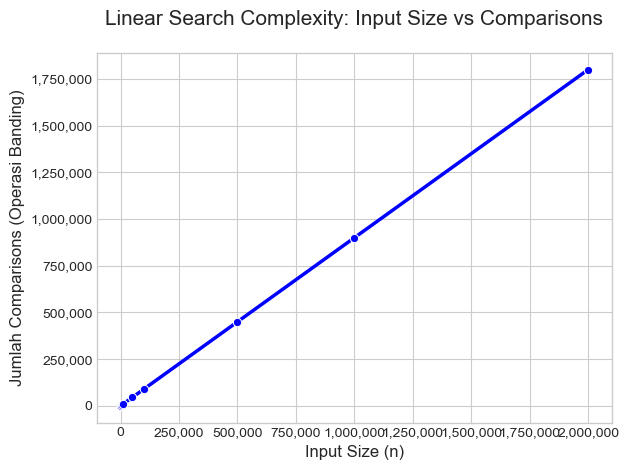

In [4]:
sns.lineplot(data=kop1, x='Input Size (n)', y='Comparisons', marker='o', linewidth=2.5, color='blue')

# Menambahkan Judul dan Label
plt.title('Linear Search Complexity: Input Size vs Comparisons', fontsize=15, pad=20)
plt.xlabel('Input Size (n)', fontsize=12)
plt.ylabel('Jumlah Comparisons (Operasi Banding)', fontsize=12)

# Format angka di sumbu agar tidak muncul notasi ilmiah (misal: 1e6)
# Agar angka 1000000 terlihat jelas sebagai 1,000,000
current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in current_values])

current_y_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(y) for y in current_y_values])

# Menampilkan grafik
plt.tight_layout()
plt.show()

C:\Users\dsapu\AppData\Local\Temp\ipykernel_4788\2357445232.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in current_values])
C:\Users\dsapu\AppData\Local\Temp\ipykernel_4788\2357445232.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(y) for y in current_y_values])


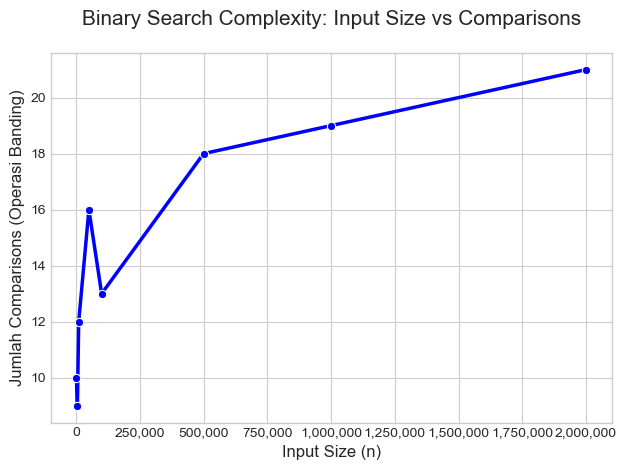

In [5]:
sns.lineplot(data=kop2, x='Input Size (n)', y='Comparisons', marker='o', linewidth=2.5, color='blue')

# Menambahkan Judul dan Label
plt.title('Binary Search Complexity: Input Size vs Comparisons', fontsize=15, pad=20)
plt.xlabel('Input Size (n)', fontsize=12)
plt.ylabel('Jumlah Comparisons (Operasi Banding)', fontsize=12)

# Format angka di sumbu agar tidak muncul notasi ilmiah (misal: 1e6)
# Agar angka 1000000 terlihat jelas sebagai 1,000,000
current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in current_values])

current_y_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(y) for y in current_y_values])

# Menampilkan grafik
plt.tight_layout()
plt.show()

In [6]:
# Statistik deskriptif
print("\n=== STATISTIK DESKRIPTIF ===")
print("\nComparisons:")
print(df_all.groupby('Algorithm')['Comparisons'].describe())

print("\n\nExecution Time (seconds):")
print(df_all.groupby('Algorithm')['Time (seconds)'].describe())


=== STATISTIK DESKRIPTIF ===

Comparisons:
                   count            mean             std         min  \
Algorithm                                                              
Binary Search   8.000000       14.750000        4.399675    9.000000   
Bubble Sort    21.000000 25249811.095238 59966349.462815   99.000000   
Insertion Sort 21.000000 18928704.142857 47837840.037042   99.000000   
Linear Search   8.000000   412425.750000   643869.270971  901.000000   
Merge Sort     21.000000    47082.095238    67804.583118  316.000000   
Quick Sort     21.000000   194629.095238   399564.951818  613.000000   
Selection Sort 21.000000 37872957.142857 69945074.029933 4950.000000   

                         25%            50%             75%              max  
Algorithm                                                                     
Binary Search      11.500000      14.500000       18.250000        21.000000  
Bubble Sort      4950.000000  124750.000000 12497149.000000 199990000.

In [7]:
# Filter data untuk visualisasi
# Search algorithms
df_search = df_all[df_all['Algorithm'].isin(['Linear Search', 'Binary Search'])]

# Sorting algorithms - Random data
df_sort_random = df_all[
    (df_all['Algorithm'].isin(['Bubble Sort', 'Insertion Sort', 'Merge Sort'])) &
    (df_all['Data Type'] == 'Random')
]

print(f"Search algorithms records: {len(df_search)}")
print(f"Sorting algorithms records (Random): {len(df_sort_random)}")

Search algorithms records: 16
Sorting algorithms records (Random): 21


### 📊 Visualisasi: Comparisons per Algoritma

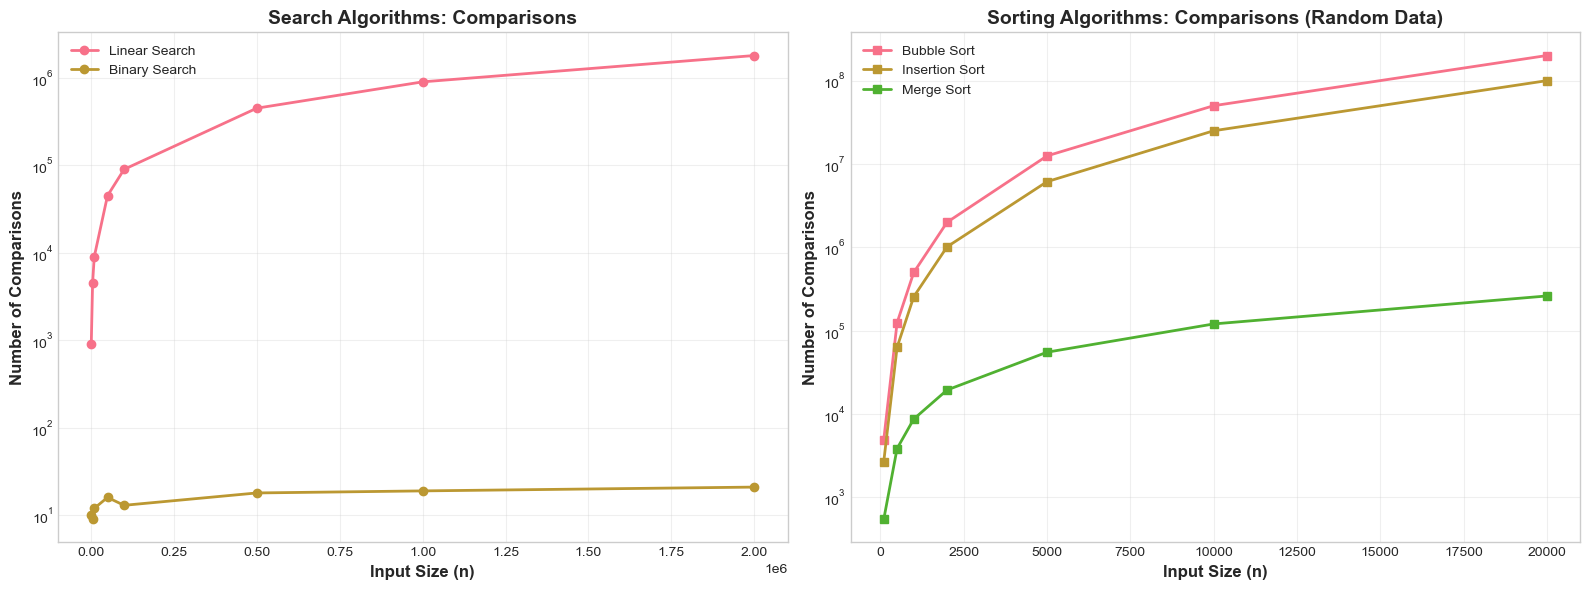

In [8]:
# Plot comparisons - Search algorithms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Search algorithms
for algo in df_search['Algorithm'].unique():
    data = df_search[df_search['Algorithm'] == algo]
    ax1.plot(data['Input Size (n)'], data['Comparisons'], 
             marker='o', linewidth=2, label=algo)

ax1.set_xlabel('Input Size (n)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Comparisons', fontsize=12, fontweight='bold')
ax1.set_title('Search Algorithms: Comparisons', fontsize=14, fontweight='bold')
ax1.legend()
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Sorting algorithms
for algo in df_sort_random['Algorithm'].unique():
    data = df_sort_random[df_sort_random['Algorithm'] == algo]
    ax2.plot(data['Input Size (n)'], data['Comparisons'], 
             marker='s', linewidth=2, label=algo)

ax2.set_xlabel('Input Size (n)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Comparisons', fontsize=12, fontweight='bold')
ax2.set_title('Sorting Algorithms: Comparisons (Random Data)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2️⃣ Summary: Best vs Worst Performers

Tabel ini menunjukkan **algoritma tercepat dan terlambat** untuk setiap ukuran input.

In [9]:
# Load summary data
df_summary = pd.read_csv(cwd.parent / 'results' /'comparison_summary.csv')

print("=== SUMMARY: FASTEST vs SLOWEST ===")
print(f"\nTotal comparisons: {len(df_summary)}")
print("\nData preview:")
df_summary.head(15)

=== SUMMARY: FASTEST vs SLOWEST ===

Total comparisons: 15

Data preview:


,Category,Input Size (n),Fastest Algorithm,Time (sec),Slowest Algorithm,Time (sec).1,Speed Difference (x)
0,Search,1000,Binary Search,0.000010,Linear Search,0.000147,14.700000
1,Search,5000,Binary Search,0.000009,Linear Search,0.000735,81.670000
2,Search,10000,Binary Search,0.000004,Linear Search,0.001062,265.500000
3,Search,50000,Binary Search,0.000009,Linear Search,0.007934,881.560000
4,Search,100000,Binary Search,0.000009,Linear Search,0.016170,1796.670000
5,Search,500000,Binary Search,0.000010,Linear Search,0.088653,8865.300000
6,Search,1000000,Binary Search,0.000011,Linear Search,0.178626,16238.730000
7,Search,2000000,Binary Search,0.000016,Linear Search,0.376893,23555.810000
8,Sorting (Random),100,Merge Sort,0.000200,Bubble Sort,0.001200,6.000000
9,Sorting (Random),500,Quick Sort,0.001000,Bubble Sort,0.019500,19.500000


In [10]:
# 1. Filter hanya kategori Search
df_search = df_summary[df_summary['Category'] == 'Search'].copy()

# 2. Ambil hanya kolom yang penting untuk perbandingan
# Asumsi: Fastest selalu Binary Search dan Slowest selalu Linear Search untuk data ini
cols_to_keep = ['Input Size (n)', 'Time (sec)', 'Time (sec).1']
comparison_table = df_search[cols_to_keep]

# 3. Rename kolom agar lebih enak dibaca
comparison_table.columns = ['Input Size', 'Binary Search (sec)', 'Linear Search (sec)']

# Tampilkan Tabel Perbandingan Bersih
print("Tabel Perbandingan Waktu Eksekusi:")
display(comparison_table)

Tabel Perbandingan Waktu Eksekusi:


,Input Size,Binary Search (sec),Linear Search (sec)
0,1000,0.000010,0.000147
1,5000,0.000009,0.000735
2,10000,0.000004,0.001062
3,50000,0.000009,0.007934
4,100000,0.000009,0.016170
5,500000,0.000010,0.088653
6,1000000,0.000011,0.178626
7,2000000,0.000016,0.376893


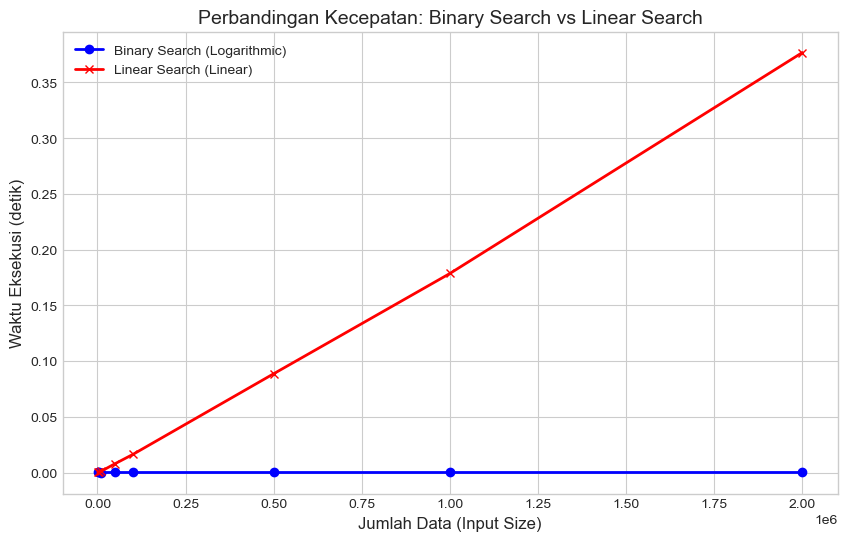

In [11]:
# Set style agar grafik terlihat profesional (seperti di paper/jurnal)
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

# Plot Garis untuk Binary Search
plt.plot(comparison_table['Input Size'], 
         comparison_table['Binary Search (sec)'], 
         marker='o', label='Binary Search (Logarithmic)', color='blue', linewidth=2)

# Plot Garis untuk Linear Search
plt.plot(comparison_table['Input Size'], 
         comparison_table['Linear Search (sec)'], 
         marker='x', label='Linear Search (Linear)', color='red', linewidth=2)

# Labeling
plt.title('Perbandingan Kecepatan: Binary Search vs Linear Search', fontsize=14)
plt.xlabel('Jumlah Data (Input Size)', fontsize=12)
plt.ylabel('Waktu Eksekusi (detik)', fontsize=12)
plt.legend()

# Tampilkan
plt.show()

In [12]:
# Analisis speed difference
print("\n=== SPEED DIFFERENCE ANALYSIS ===")
print("\nSearch Algorithms:")
search_summary = df_summary[df_summary['Category'] == 'Search']
print(f"Average speedup: {search_summary['Speed Difference (x)'].mean():.2f}x")
print(f"Max speedup: {search_summary['Speed Difference (x)'].max():.2f}x")
print(f"Min speedup: {search_summary['Speed Difference (x)'].min():.2f}x")

print("\nSorting Algorithms (Random):")
sort_summary = df_summary[df_summary['Category'] == 'Sorting (Random)']
print(f"Average speedup: {sort_summary['Speed Difference (x)'].mean():.2f}x")
print(f"Max speedup: {sort_summary['Speed Difference (x)'].max():.2f}x")
print(f"Min speedup: {sort_summary['Speed Difference (x)'].min():.2f}x")


=== SPEED DIFFERENCE ANALYSIS ===

Search Algorithms:
Average speedup: 6462.49x
Max speedup: 23555.81x
Min speedup: 14.70x

Sorting Algorithms (Random):
Average speedup: 151.16x
Max speedup: 504.63x
Min speedup: 6.00x


### 📊 Visualisasi: Speed Difference

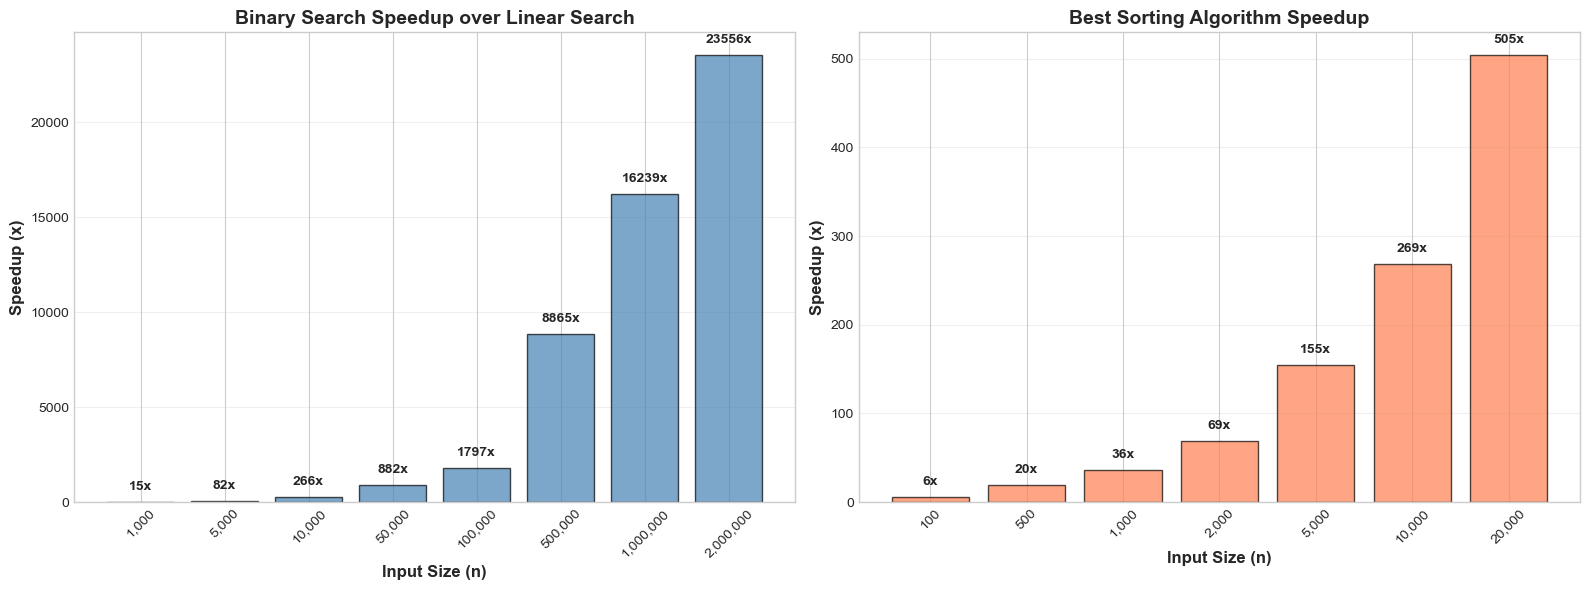

In [13]:
# Plot speed difference
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Search
search_data = df_summary[df_summary['Category'] == 'Search']
axes[0].bar(range(len(search_data)), search_data['Speed Difference (x)'], 
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(search_data)))
axes[0].set_xticklabels([f"{n:,}" for n in search_data['Input Size (n)']], rotation=45)
axes[0].set_xlabel('Input Size (n)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Speedup (x)', fontsize=12, fontweight='bold')
axes[0].set_title('Binary Search Speedup over Linear Search', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(search_data['Speed Difference (x)']):
    axes[0].text(i, v + max(search_data['Speed Difference (x)'])*0.02, 
                f'{v:.0f}x', ha='center', va='bottom', fontweight='bold')

# Sorting
sort_data = df_summary[df_summary['Category'] == 'Sorting (Random)']
axes[1].bar(range(len(sort_data)), sort_data['Speed Difference (x)'], 
            color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(sort_data)))
axes[1].set_xticklabels([f"{n:,}" for n in sort_data['Input Size (n)']], rotation=45)
axes[1].set_xlabel('Input Size (n)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Speedup (x)', fontsize=12, fontweight='bold')
axes[1].set_title('Best Sorting Algorithm Speedup', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(sort_data['Speed Difference (x)']):
    axes[1].text(i, v + max(sort_data['Speed Difference (x)'])*0.02, 
                f'{v:.0f}x', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3️⃣ Speedup & Comparison Reduction Analysis

Analisis detail **speedup** dan **pengurangan jumlah komparasi** antar algoritma.

In [14]:
# Load speedup data
df_speedup = pd.read_csv('comparison_speedup.csv')

print("=== SPEEDUP ANALYSIS ===")
print(f"\nTotal comparisons: {len(df_speedup)}")
print("\nData preview:")
df_speedup.head(15)

=== SPEEDUP ANALYSIS ===

Total comparisons: 15

Data preview:


,Comparison,Input Size (n),Algorithm A,Algorithm A Time,Algorithm B,Algorithm B Time,Speedup (A/B),Comparison Reduction (%)
0,Search Algorithms,1000,Linear Search,0.000147,Binary Search,0.000010,14.700000,98.890000
1,Search Algorithms,5000,Linear Search,0.000735,Binary Search,0.000009,81.670000,99.800000
2,Search Algorithms,10000,Linear Search,0.001062,Binary Search,0.000004,265.500000,99.870000
3,Search Algorithms,50000,Linear Search,0.007934,Binary Search,0.000009,881.560000,99.960000
4,Search Algorithms,100000,Linear Search,0.016170,Binary Search,0.000009,1796.670000,99.990000
5,Search Algorithms,500000,Linear Search,0.088653,Binary Search,0.000010,8865.300000,100.000000
6,Search Algorithms,1000000,Linear Search,0.178626,Binary Search,0.000011,16238.730000,100.000000
7,Search Algorithms,2000000,Linear Search,0.376893,Binary Search,0.000016,23555.810000,100.000000
8,Sorting (Random),100,Bubble Sort,0.001200,Quick Sort,0.000200,6.000000,87.560000
9,Sorting (Random),500,Bubble Sort,0.019500,Quick Sort,0.001000,19.500000,96.350000


In [15]:
# Analisis comparison reduction
print("\n=== COMPARISON REDUCTION ANALYSIS ===")

# Search
search_speedup = df_speedup[df_speedup['Comparison'] == 'Search Algorithms']
print("\nSearch Algorithms (Linear vs Binary):")
print(f"Average comparison reduction: {search_speedup['Comparison Reduction (%)'].mean():.2f}%")
print(f"Max comparison reduction: {search_speedup['Comparison Reduction (%)'].max():.2f}%")
print(f"Average speedup: {search_speedup['Speedup (A/B)'].mean():.2f}x")

# Sorting - Bubble vs Merge
bubble_merge = df_speedup[
    (df_speedup['Comparison'] == 'Sorting (Random)') & 
    (df_speedup['Algorithm A'] == 'Bubble Sort')
]
print("\nSorting (Bubble vs Merge):")
print(f"Average comparison reduction: {bubble_merge['Comparison Reduction (%)'].mean():.2f}%")
print(f"Average speedup: {bubble_merge['Speedup (A/B)'].mean():.2f}x")

# Sorting - Insertion vs Merge
insertion_merge = df_speedup[
    (df_speedup['Comparison'] == 'Sorting (Random)') & 
    (df_speedup['Algorithm A'] == 'Insertion Sort')
]
print("\nSorting (Insertion vs Merge):")
print(f"Average comparison reduction: {insertion_merge['Comparison Reduction (%)'].mean():.2f}%")
print(f"Average speedup: {insertion_merge['Speedup (A/B)'].mean():.2f}x")


=== COMPARISON REDUCTION ANALYSIS ===

Search Algorithms (Linear vs Binary):
Average comparison reduction: 99.81%
Max comparison reduction: 100.00%
Average speedup: 6462.49x

Sorting (Bubble vs Merge):
Average comparison reduction: 97.08%
Average speedup: 134.88x

Sorting (Insertion vs Merge):
Average comparison reduction: nan%
Average speedup: nanx


### 📊 Visualisasi: Speedup Trends

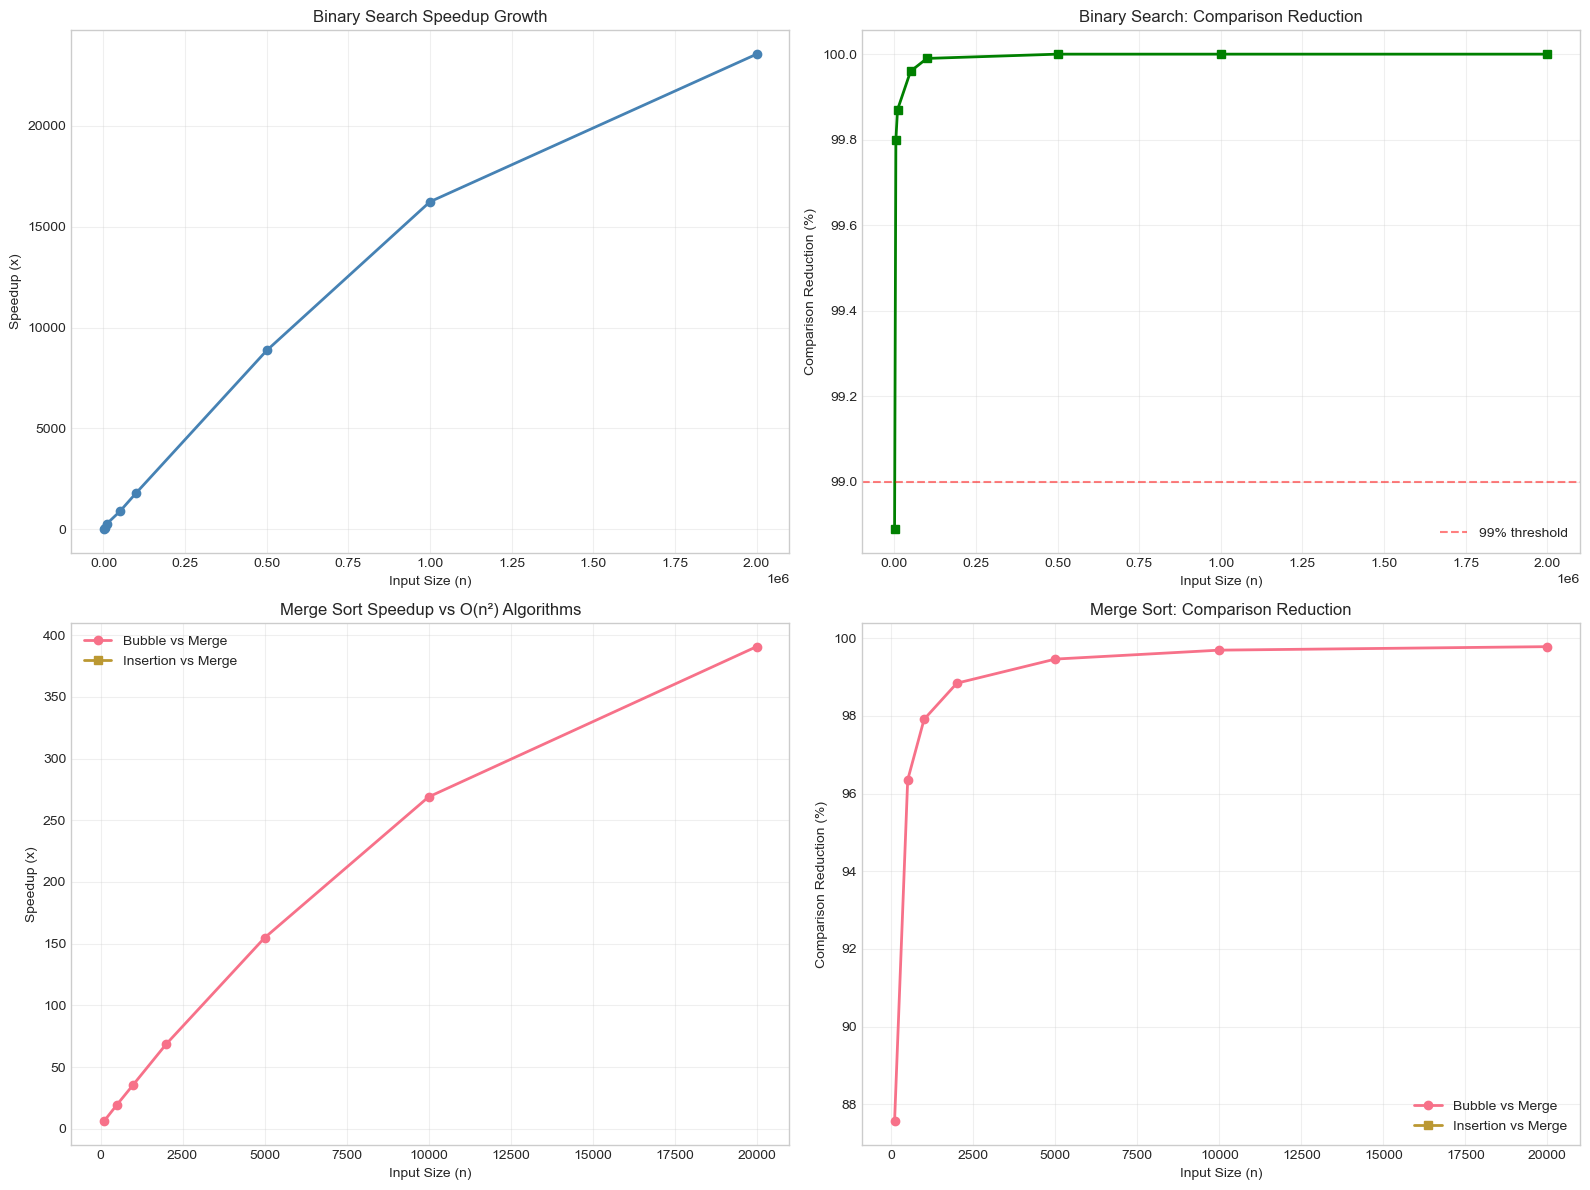

In [16]:
# Plot speedup trends
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Search - Speedup
search_data = df_speedup[df_speedup['Comparison'] == 'Search Algorithms']
axes[0, 0].plot(search_data['Input Size (n)'], search_data['Speedup (A/B)'], 
                marker='o', linewidth=2, color='steelblue')
axes[0, 0].set_xlabel('Input Size (n)')
axes[0, 0].set_ylabel('Speedup (x)')
axes[0, 0].set_title('Binary Search Speedup Growth')
axes[0, 0].grid(True, alpha=0.3)

# Search - Comparison Reduction
axes[0, 1].plot(search_data['Input Size (n)'], search_data['Comparison Reduction (%)'], 
                marker='s', linewidth=2, color='green')
axes[0, 1].set_xlabel('Input Size (n)')
axes[0, 1].set_ylabel('Comparison Reduction (%)')
axes[0, 1].set_title('Binary Search: Comparison Reduction')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=99, color='r', linestyle='--', alpha=0.5, label='99% threshold')
axes[0, 1].legend()

# Sorting - Speedup Comparison
bubble_data = df_speedup[
    (df_speedup['Comparison'] == 'Sorting (Random)') & 
    (df_speedup['Algorithm A'] == 'Bubble Sort')
]
insertion_data = df_speedup[
    (df_speedup['Comparison'] == 'Sorting (Random)') & 
    (df_speedup['Algorithm A'] == 'Insertion Sort')
]

axes[1, 0].plot(bubble_data['Input Size (n)'], bubble_data['Speedup (A/B)'], 
                marker='o', linewidth=2, label='Bubble vs Merge')
axes[1, 0].plot(insertion_data['Input Size (n)'], insertion_data['Speedup (A/B)'], 
                marker='s', linewidth=2, label='Insertion vs Merge')
axes[1, 0].set_xlabel('Input Size (n)')
axes[1, 0].set_ylabel('Speedup (x)')
axes[1, 0].set_title('Merge Sort Speedup vs O(n²) Algorithms')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Sorting - Comparison Reduction
axes[1, 1].plot(bubble_data['Input Size (n)'], bubble_data['Comparison Reduction (%)'], 
                marker='o', linewidth=2, label='Bubble vs Merge')
axes[1, 1].plot(insertion_data['Input Size (n)'], insertion_data['Comparison Reduction (%)'], 
                marker='s', linewidth=2, label='Insertion vs Merge')
axes[1, 1].set_xlabel('Input Size (n)')
axes[1, 1].set_ylabel('Comparison Reduction (%)')
axes[1, 1].set_title('Merge Sort: Comparison Reduction')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4️⃣ Growth Rate Analysis - Verifikasi Big-O

Analisis empiris untuk **membuktikan kompleksitas Big-O** dari masing-masing algoritma.

In [17]:
# Load growth rate data
df_growth = pd.read_csv('comparison_growth_rate.csv')

print("=== GROWTH RATE ANALYSIS ===")
print(f"\nTotal comparisons: {len(df_growth)}")
print("\nData preview:")
df_growth.sort_values(by='Algorithm').head(15)

=== GROWTH RATE ANALYSIS ===

Total comparisons: 38

Data preview:


,Algorithm,Size 1,Comparisons 1,Size 2,Comparisons 2,Size Growth (x),Comparisons Growth (x),Theoretical Complexity,Matches Theory?
1,Binary Search,1000,10,5000,9,5.000000,0.900000,O(log n),Yes
3,Binary Search,5000,9,10000,12,2.000000,1.330000,O(log n),Close
5,Binary Search,10000,12,50000,16,5.000000,1.330000,O(log n),Yes
7,Binary Search,50000,16,100000,13,2.000000,0.810000,O(log n),Yes
9,Binary Search,100000,13,500000,18,5.000000,1.380000,O(log n),Yes
11,Binary Search,500000,18,1000000,19,2.000000,1.060000,O(log n),Close
13,Binary Search,1000000,19,2000000,21,2.000000,1.110000,O(log n),Close
18,Bubble Sort,500,124714,1000,499434,2.000000,4.000000,O(n^2),Yes
34,Bubble Sort,10000,49991597,20000,199980820,2.000000,4.000000,O(n^2),Yes
30,Bubble Sort,5000,12497149,10000,49991597,2.000000,4.000000,O(n^2),Yes


In [18]:
# Analisis per algoritma
print("\n=== GROWTH RATE VERIFICATION ===")

for algo in df_growth['Algorithm'].unique():
    algo_data = df_growth[df_growth['Algorithm'] == algo]
    
    print(f"\n{algo}:")
    print(f"  Theoretical: {algo_data['Theoretical Complexity'].iloc[0]}")
    print(f"  Average size growth: {algo_data['Size Growth (x)'].mean():.2f}x")
    print(f"  Average comparisons growth: {algo_data['Comparisons Growth (x)'].mean():.2f}x")
    
    matches = algo_data['Matches Theory?'].value_counts()
    print(f"  Matches theory: {matches.get('Yes', 0)}/{len(algo_data)} tests")


=== GROWTH RATE VERIFICATION ===

Linear Search:
  Theoretical: O(n)
  Average size growth: 3.29x
  Average comparisons growth: 3.29x
  Matches theory: 7/7 tests

Binary Search:
  Theoretical: O(log n)
  Average size growth: 3.29x
  Average comparisons growth: 1.13x
  Matches theory: 4/7 tests

Bubble Sort:
  Theoretical: O(n^2)
  Average size growth: 2.58x
  Average comparisons growth: 7.92x
  Matches theory: 6/6 tests

Selection Sort:
  Theoretical: O(n^2)
  Average size growth: 2.58x
  Average comparisons growth: 7.91x
  Matches theory: 6/6 tests

Merge Sort:
  Theoretical: O(n log n)
  Average size growth: 2.58x
  Average comparisons growth: 3.12x
  Matches theory: 6/6 tests

Quick Sort:
  Theoretical: O(n log n)
  Average size growth: 2.58x
  Average comparisons growth: 3.33x
  Matches theory: 6/6 tests


### 📊 Visualisasi: Growth Rate Verification

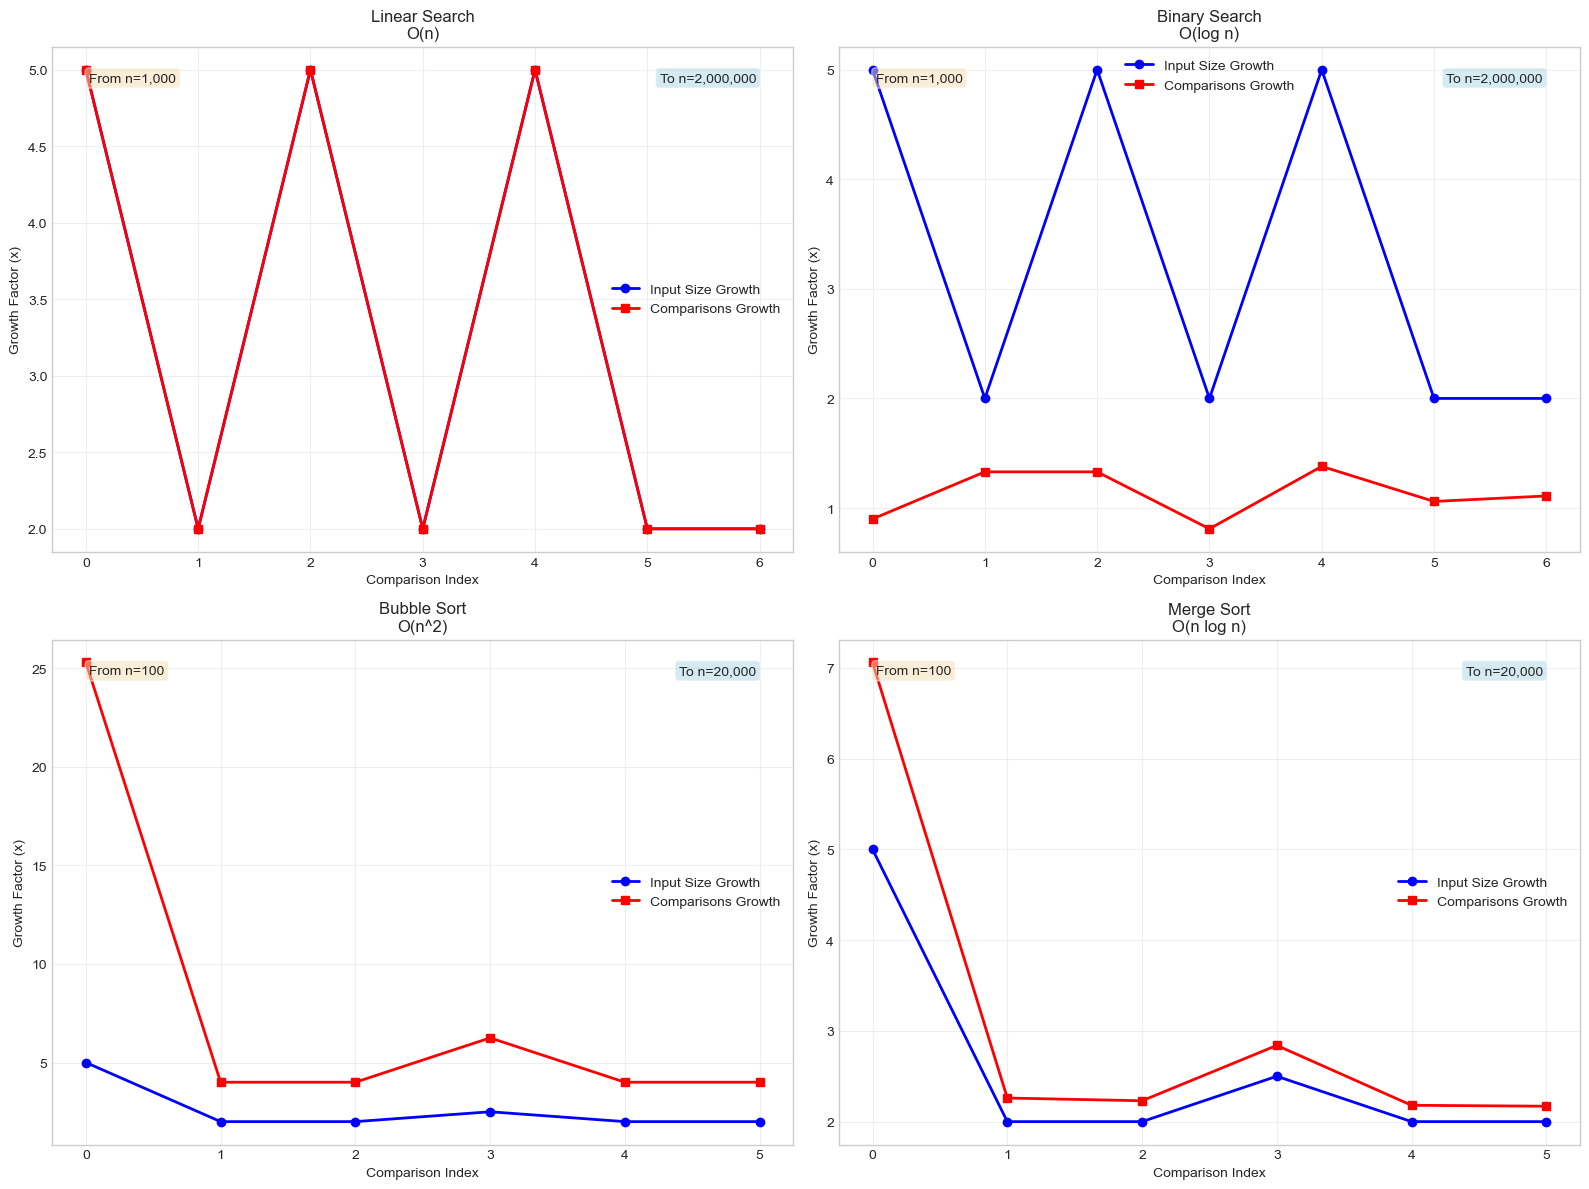

In [19]:
# Plot growth rate comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

algorithms = [
    ('Linear Search', axes[0, 0]),
    ('Binary Search', axes[0, 1]),
    ('Bubble Sort', axes[1, 0]),
    ('Merge Sort', axes[1, 1])
]

for algo_name, ax in algorithms:
    data = df_growth[df_growth['Algorithm'] == algo_name]
    
    if len(data) > 0:
        x = range(len(data))
        
        # Plot size growth dan comparisons growth
        ax.plot(x, data['Size Growth (x)'], 
               marker='o', linewidth=2, label='Input Size Growth', color='blue')
        ax.plot(x, data['Comparisons Growth (x)'], 
               marker='s', linewidth=2, label='Comparisons Growth', color='red')
        
        ax.set_xlabel('Comparison Index')
        ax.set_ylabel('Growth Factor (x)')
        ax.set_title(f"{algo_name}\n{data['Theoretical Complexity'].iloc[0]}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add annotations untuk first dan last point
        if len(data) > 0:
            first_size = data.iloc[0]['Size 1']
            last_size = data.iloc[-1]['Size 2']
            ax.text(0.05, 0.95, f"From n={first_size:,}", 
                   transform=ax.transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            ax.text(0.95, 0.95, f"To n={last_size:,}", 
                   transform=ax.transAxes, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

### 📊 Heatmap: Growth Rate Matrix

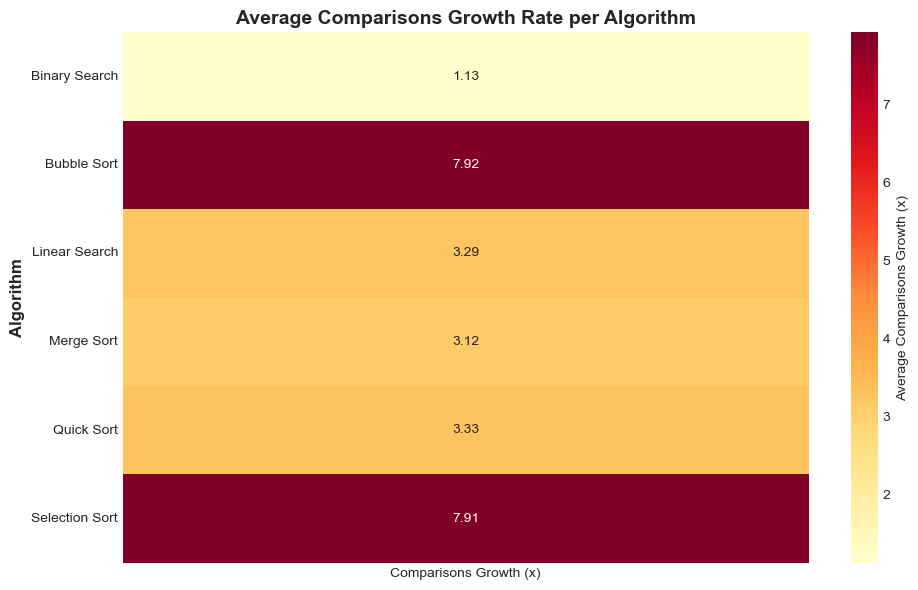


Interpretation:
- Nilai lebih kecil = pertumbuhan lebih lambat (lebih efisien)
- Nilai lebih besar = pertumbuhan lebih cepat (kurang efisien untuk data besar)


In [20]:
# Create pivot table untuk heatmap
pivot_data = df_growth.pivot_table(
    values='Comparisons Growth (x)', 
    index='Algorithm', 
    aggfunc='mean'
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Average Comparisons Growth (x)'}, ax=ax)
ax.set_title('Average Comparisons Growth Rate per Algorithm', fontsize=14, fontweight='bold')
ax.set_ylabel('Algorithm', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Nilai lebih kecil = pertumbuhan lebih lambat (lebih efisien)")
print("- Nilai lebih besar = pertumbuhan lebih cepat (kurang efisien untuk data besar)")

---
## 5️⃣ Summary & Key Insights

Ringkasan temuan utama dari analisis kompleksitas algoritma.

In [21]:
print("="*80)
print("KEY INSIGHTS - ANALISIS KOMPLEKSITAS ALGORITMA")
print("="*80)

print("\n1. SEARCH ALGORITHMS:")
print("   Binary Search vs Linear Search:")
search_max = df_summary[df_summary['Category'] == 'Search']['Speed Difference (x)'].max()
print(f"   - Maximum speedup: {search_max:.0f}x lebih cepat")
comp_reduction = df_speedup[df_speedup['Comparison'] == 'Search Algorithms']['Comparison Reduction (%)'].max()
print(f"   - Maximum comparison reduction: {comp_reduction:.2f}%")
print(f"   ✓ Binary Search (O(log n)) JAUH lebih efisien untuk data besar")

print("\n2. SORTING ALGORITHMS (Random Data):")
sort_max = df_summary[df_summary['Category'] == 'Sorting (Random)']['Speed Difference (x)'].max()
print(f"   Merge Sort vs Bubble Sort:")
print(f"   - Maximum speedup: {sort_max:.0f}x lebih cepat")
bubble_reduction = bubble_merge['Comparison Reduction (%)'].max()
print(f"   - Maximum comparison reduction: {bubble_reduction:.2f}%")
print(f"   ✓ Merge Sort (O(n log n)) mendominasi untuk data besar")

print("\n3. GROWTH RATE VERIFICATION:")
for algo in ['Linear Search', 'Binary Search', 'Bubble Sort', 'Merge Sort']:
    data = df_growth[df_growth['Algorithm'] == algo]
    if len(data) > 0:
        complexity = data['Theoretical Complexity'].iloc[0]
        matches = data['Matches Theory?'].value_counts().get('Yes', 0)
        total = len(data)
        print(f"   {algo}: {complexity}")
        print(f"   - Verified: {matches}/{total} tests match theory")

print("\n4. PRACTICAL RECOMMENDATIONS:")
print("   • Small data (n < 100): Any algorithm acceptable")
print("   • Medium data (100 < n < 1000): Insertion Sort reasonable")
print("   • Large data (n > 1000): Use O(n log n) algorithms")
print("   • Sorted/nearly sorted: Insertion Sort optimal (O(n))")
print("   • Search in sorted data: ALWAYS use Binary Search")

print("\n" + "="*80)
print("CONCLUSION: Big-O notation accurately predicts algorithm performance!")
print("="*80)

KEY INSIGHTS - ANALISIS KOMPLEKSITAS ALGORITMA

1. SEARCH ALGORITHMS:
   Binary Search vs Linear Search:
   - Maximum speedup: 23556x lebih cepat
   - Maximum comparison reduction: 100.00%
   ✓ Binary Search (O(log n)) JAUH lebih efisien untuk data besar

2. SORTING ALGORITHMS (Random Data):
   Merge Sort vs Bubble Sort:
   - Maximum speedup: 505x lebih cepat
   - Maximum comparison reduction: 99.78%
   ✓ Merge Sort (O(n log n)) mendominasi untuk data besar

3. GROWTH RATE VERIFICATION:
   Linear Search: O(n)
   - Verified: 7/7 tests match theory
   Binary Search: O(log n)
   - Verified: 4/7 tests match theory
   Bubble Sort: O(n^2)
   - Verified: 6/6 tests match theory
   Merge Sort: O(n log n)
   - Verified: 6/6 tests match theory

4. PRACTICAL RECOMMENDATIONS:
   • Small data (n < 100): Any algorithm acceptable
   • Medium data (100 < n < 1000): Insertion Sort reasonable
   • Large data (n > 1000): Use O(n log n) algorithms
   • Sorted/nearly sorted: Insertion Sort optimal (O(n))
  

---
## 6️⃣ Export Summary ke File

Export key insights ke file text untuk presentasi.

In [22]:
# # Export summary
# with open('analysis_summary.txt', 'w') as f:
#     f.write("="*80 + "\n")
#     f.write("ANALISIS KOMPLEKSITAS ALGORITMA - SUMMARY\n")
#     f.write("Kelompok 2\n")
#     f.write("="*80 + "\n\n")
    
#     f.write("ALGORITHMS TESTED:\n")
#     for algo in df_all['Algorithm'].unique():
#         complexity = df_all[df_all['Algorithm'] == algo]['Complexity Class'].iloc[0]
#         f.write(f"  - {algo}: {complexity}\n")
    
#     f.write("\n" + "="*80 + "\n")
#     f.write("KEY FINDINGS:\n")
#     f.write("="*80 + "\n\n")
    
#     f.write(f"1. Binary Search is {search_max:.0f}x faster than Linear Search\n")
#     f.write(f"   (Comparison reduction: {comp_reduction:.2f}%)\n\n")
    
#     f.write(f"2. Merge Sort is {sort_max:.0f}x faster than Bubble Sort\n")
#     f.write(f"   (Comparison reduction: {bubble_reduction:.2f}%)\n\n")
    
#     f.write("3. Growth Rate Verification:\n")
#     for algo in ['Linear Search', 'Binary Search', 'Bubble Sort', 'Merge Sort']:
#         data = df_growth[df_growth['Algorithm'] == algo]
#         if len(data) > 0:
#             complexity = data['Theoretical Complexity'].iloc[0]
#             matches = data['Matches Theory?'].value_counts().get('Yes', 0)
#             total = len(data)
#             f.write(f"   {algo}: {complexity} - {matches}/{total} verified\n")

# print("✓ Summary exported to: analysis_summary.txt")

---
## 🎯 End of Analysis

**Files Generated:**
- `analysis_summary.txt` - Summary hasil analisis
- All visualizations displayed in notebook

**Next Steps:**
1. Review all visualizations
2. Prepare presentation slides
3. Include key insights in report

---
*Notebook by Kelompok 2 - Analisis Kompleksitas Algoritma*